<a href="https://colab.research.google.com/github/zosiawidawska/Pliki/blob/main/ZME1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import numpy as np
import pandas as pd
import statistics as st
from scipy.stats import gmean, skew, kurtosis, probplot, zscore
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import parallel_coordinates, scatter_matrix

In [11]:
###Zadanie 1
data = pd.read_csv('carbig.csv')
np.random.seed(int(6.24 * 2026))

# Replace NaN
columns = ['Acceleration', 'Displacement', 'Horsepower', 'Weight', 'MPG']
for col in columns:
  data[col] = data[col].fillna(data[col].mode()[0])

# Select columns
x = data[columns].values

# Add random noise (1% variation)
noise_multiplier = 1 + (np.random.rand(*x.shape) * 2 - 1) / 100
x = x * noise_multiplier

In [ ]:
data

,Model,Origin,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model_Year
0,chevrolet chevelle malibu,USA,18.0,8,307.0,130.0,3504,12.0,70
1,buick skylark 320,USA,15.0,8,350.0,165.0,3693,11.5,70
2,plymouth satellite,USA,18.0,8,318.0,150.0,3436,11.0,70
3,amc rebel sst,USA,16.0,8,304.0,150.0,3433,12.0,70
4,ford torino,USA,17.0,8,302.0,140.0,3449,10.5,70
...,...,...,...,...,...,...,...,...,...
401,ford mustang gl,USA,27.0,4,140.0,86.0,2790,15.6,82
402,volkswagen pickup,Germany,44.0,4,97.0,52.0,2130,24.6,82
403,dodge rampage,USA,32.0,4,135.0,84.0,2295,11.6,82
404,ford ranger,USA,28.0,4,120.0,79.0,2625,18.6,82


In [13]:
#ZADANIE 2
df_num = pd.DataFrame(x, columns=columns)

stats_dict = {
    'Min': df_num.min(),
    'Max': df_num.max(),
    'Średnia arytmetyczna': df_num.mean(),
    'Mediana': df_num.median(),
    'Moda': df_num.mode().iloc[0],
    'Średnia geometryczna': [gmean(df_num[col]) for col in columns],
    'Średnia harmoniczna': [st.harmonic_mean(df_num[col]) for col in columns]
}

stats_df = pd.DataFrame(stats_dict)
display(stats_df)

,Min,Max,Średnia arytmetyczna,Mediana,Moda,Średnia geometryczna,Średnia harmoniczna
Acceleration,7.930027,24.752565,15.520708,15.426158,7.930027,15.263405,14.996989
Displacement,67.462513,458.447235,194.645155,149.711970,67.462513,168.785232,147.806250
Horsepower,45.937558,230.481541,105.750664,95.151131,45.937558,99.416438,93.826757
Weight,1616.506656,5112.957504,2979.681525,2822.819924,1616.506656,2864.025103,2755.537028
MPG,8.947122,46.990324,23.301698,22.401383,8.947122,21.989558,20.722086


,Rozstęp,Q1,Q2 (Mediana),Q3,Rozstęp międzykwartylowy (IQR),Odchylenie ćwiartkowe,Typowy obszar zmienności
Acceleration,16.822538,13.677136,15.426158,17.112367,3.435232,1.717616,18.323536
Displacement,390.984721,104.270081,149.711970,299.974740,195.704659,97.852329,299.556327
Horsepower,184.543983,75.877008,95.151131,132.159513,56.282504,28.141252,144.573584
Weight,3496.450848,2220.898395,2822.819924,3636.013095,1415.114701,707.557350,3827.484244
MPG,38.043202,16.930711,22.401383,29.025135,12.094424,6.047212,31.179273


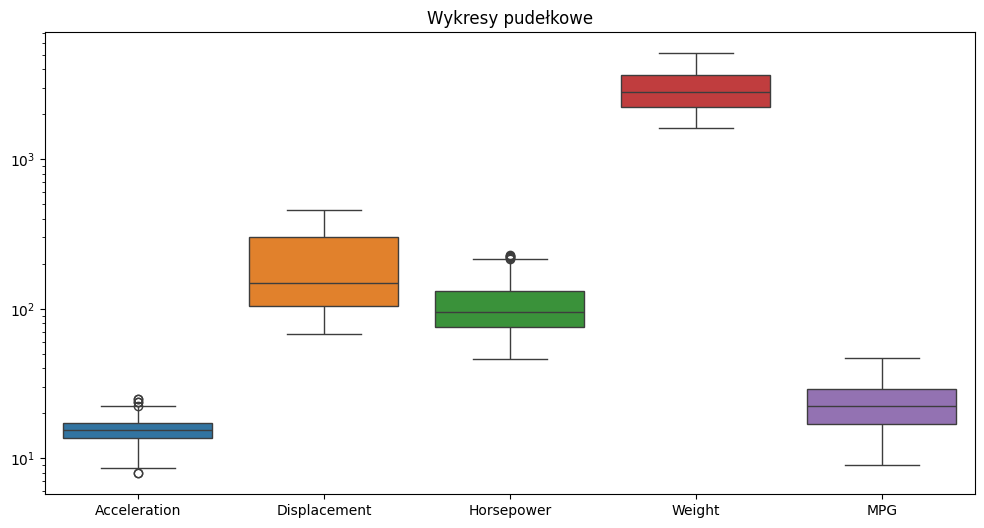

In [17]:
#ZADANIE 3
q1 = df_num.quantile(0.25)
q3 = df_num.quantile(0.75)
iqr = q3 - q1

var_stats = pd.DataFrame({
    'Rozstęp': df_num.max() - df_num.min(),
    'Q1': q1,
    'Q2 (Mediana)': df_num.median(),
    'Q3': q3,
    'Rozstęp międzykwartylowy (IQR)': iqr,
    'Odchylenie ćwiartkowe': iqr / 2
})

mean_val = df_num.mean()
std_val = df_num.std()
var_stats['Typowy obszar zmienności'] = mean_val - std_val
var_stats['Typowy obszar zmienności'] = mean_val + std_val

display(var_stats)

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_num)
plt.title("Wykresy pudełkowe")
plt.yscale('log')
plt.show()



In [34]:
#ZADANIE 4
mean_val = df_num.mean()
std_val = df_num.std()
q_deviation = (q3 - q1) / 2
median_val = df_num.median()

dispersion_stats = pd.DataFrame({
    'Wariancja': df_num.var(),
    'Odchylenie standardowe': df_num.std(),
    'Odchylenie przecietne': (df_num - mean_val).abs().mean(),
    'Klasyczny współczynnik zmienności': (std_val/mean_val) * 100,
    'Pozycyjny współczynnik zmienności': (q_deviation/median_val) * 100,
    'Typowy obszar zmiennosci (min)': mean_val - std_val,
    'Typowy obszar zmiennosci (max)': mean_val + std_val
})

display(dispersion_stats)

,Wariancja,Odchylenie standardowe,Odchylenie przecietne,Klasyczny współczynnik zmienności,Pozycyjny współczynnik zmienności,Typowy obszar zmiennosci (min),Typowy obszar zmiennosci (max)
Acceleration,7.855842,2.802828,2.180838,18.058631,11.134437,12.717881,18.323536
Displacement,11006.353912,104.911172,92.165966,53.898681,65.360391,89.733984,299.556327
Horsepower,1507.219076,38.822919,31.144027,36.711750,29.575321,66.927745,144.573584
Weight,718769.450019,847.802719,721.344847,28.452796,25.065621,2131.878806,3827.484244
MPG,62.056191,7.877575,6.597849,33.806872,26.994816,15.424123,31.179273


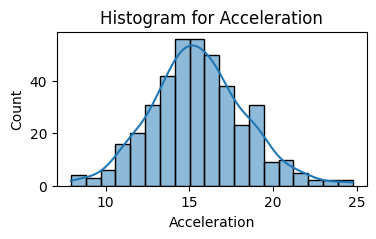

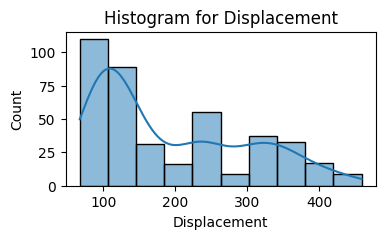

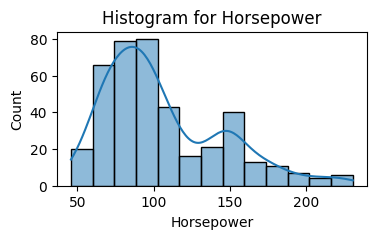

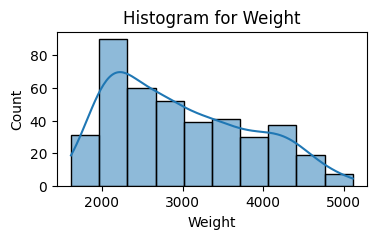

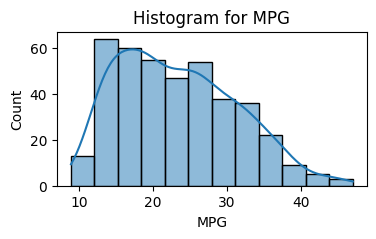

In [24]:
#ZADANIE 5
for column in df_num.columns:
    plt.figure(figsize=(4, 2))
    sns.histplot(df_num[column], kde=True)
    plt.title(f'Histogram for {column}')
    plt.xlabel(column)
    plt.show()

In [35]:
#ZADANIE 6
shape_stats = pd.DataFrame({
    'Skewness': df_num.apply(skew),
    'Kurtosis': df_num.apply(kurtosis)
})

display(shape_stats)

,Skewness,Kurtosis
Acceleration,0.231201,0.369311
Displacement,0.693363,-0.811774
Horsepower,0.979425,0.398001
Weight,0.502365,-0.833993
MPG,0.474291,-0.514667


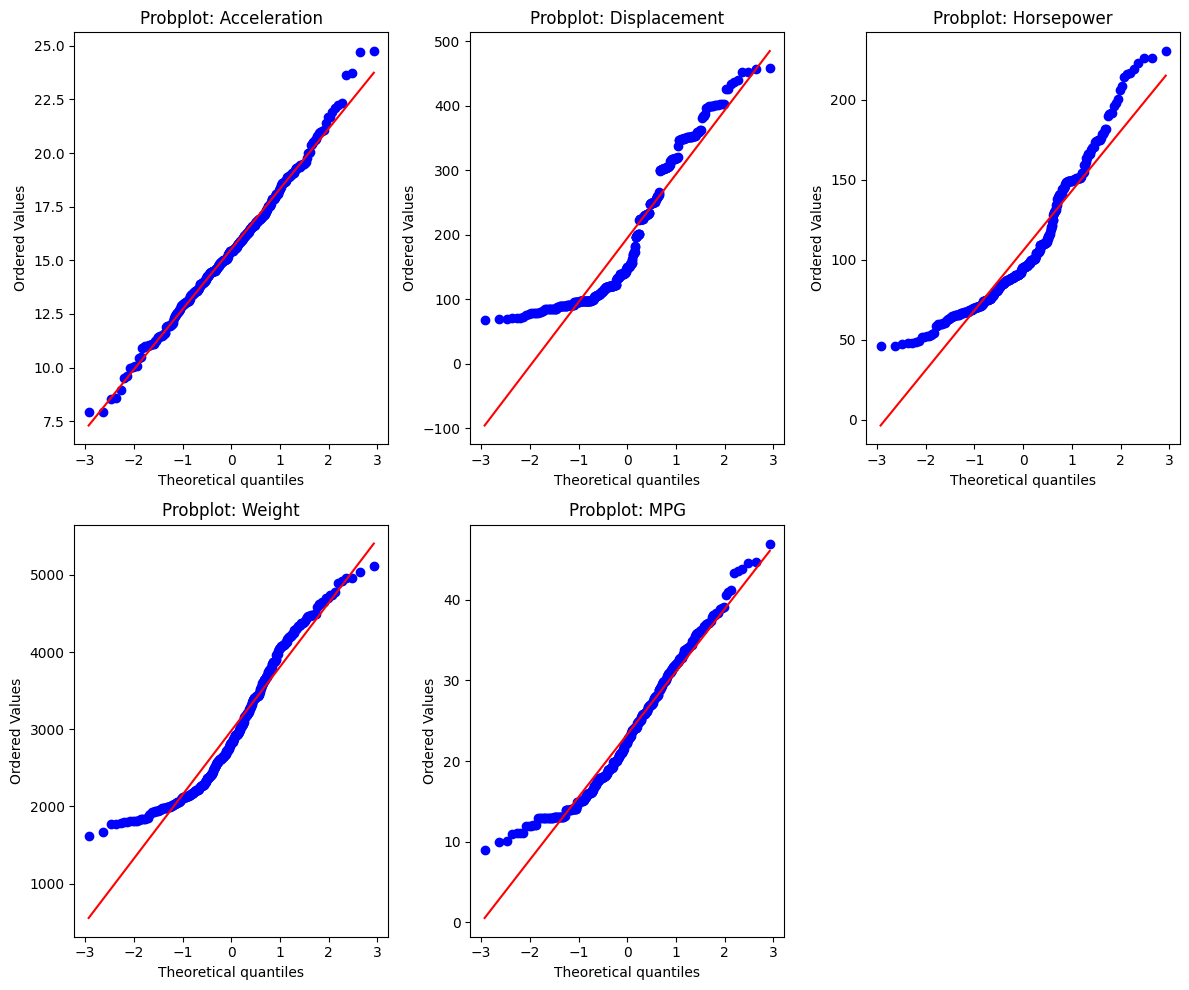

In [40]:
#ZADANIE 7
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(columns):
    probplot(df_num[col], dist="norm", plot=axes[i])
    axes[i].set_title(f'Probplot: {col}')

fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

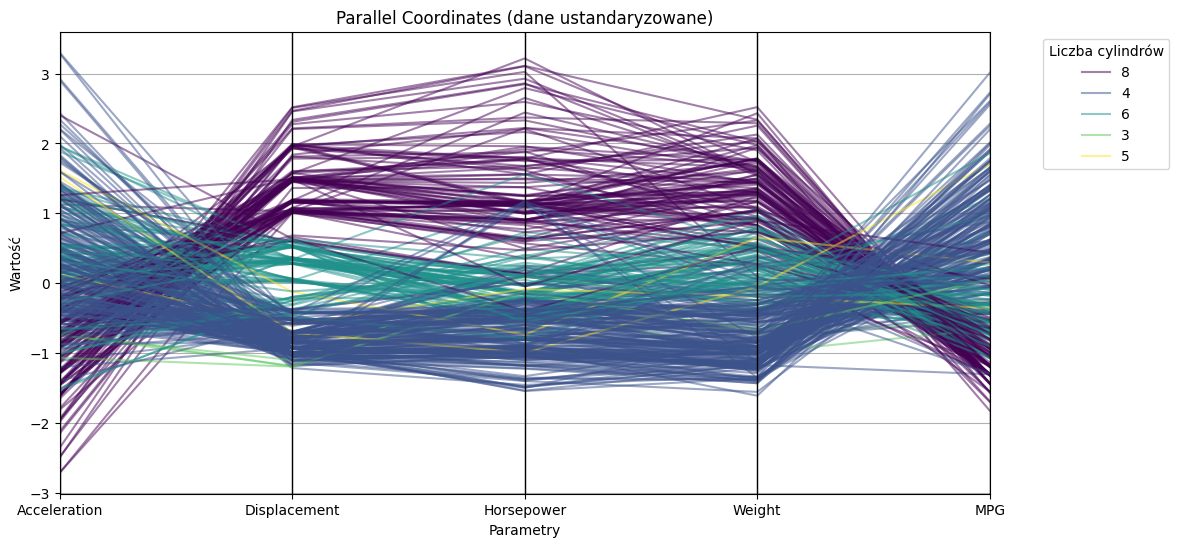

In [43]:
#ZADANIE 8
df_standardized = df_num.apply(zscore)

df_standardized['Cylinders'] = data['Cylinders'].values

plt.figure(figsize=(12, 6))
parallel_coordinates(df_standardized, 'Cylinders', colormap='viridis', alpha=0.5)
plt.title("Parallel Coordinates (dane ustandaryzowane)")
plt.xlabel("Parametry")
plt.ylabel("Wartość")
plt.legend(title="Liczba cylindrów", bbox_to_anchor=(1.05, 1))
plt.show()

,Acceleration,Displacement,Horsepower,Weight,MPG
Acceleration,1.000000,-0.558484,-0.674436,-0.431767,0.424371
Displacement,-0.558484,1.000000,0.874418,0.932033,-0.793344
Horsepower,-0.674436,0.874418,1.000000,0.843288,-0.747071
Weight,-0.431767,0.932033,0.843288,1.000000,-0.821800
MPG,0.424371,-0.793344,-0.747071,-0.821800,1.000000


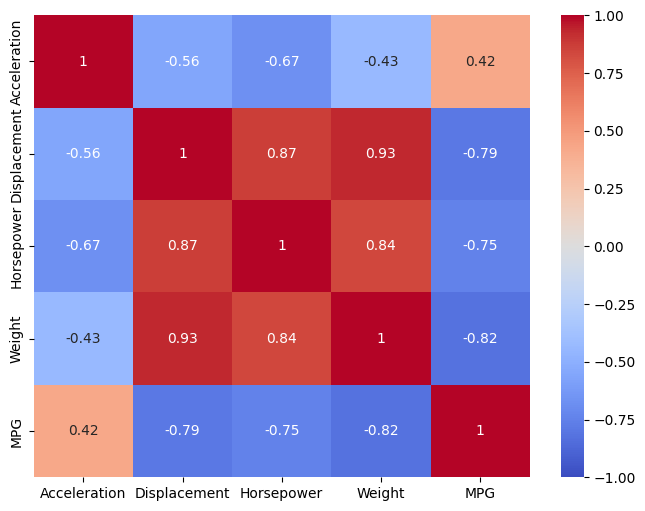

In [44]:
#ZADANIE 9
correlation_matrix = df_num.corr()
display(correlation_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.show()

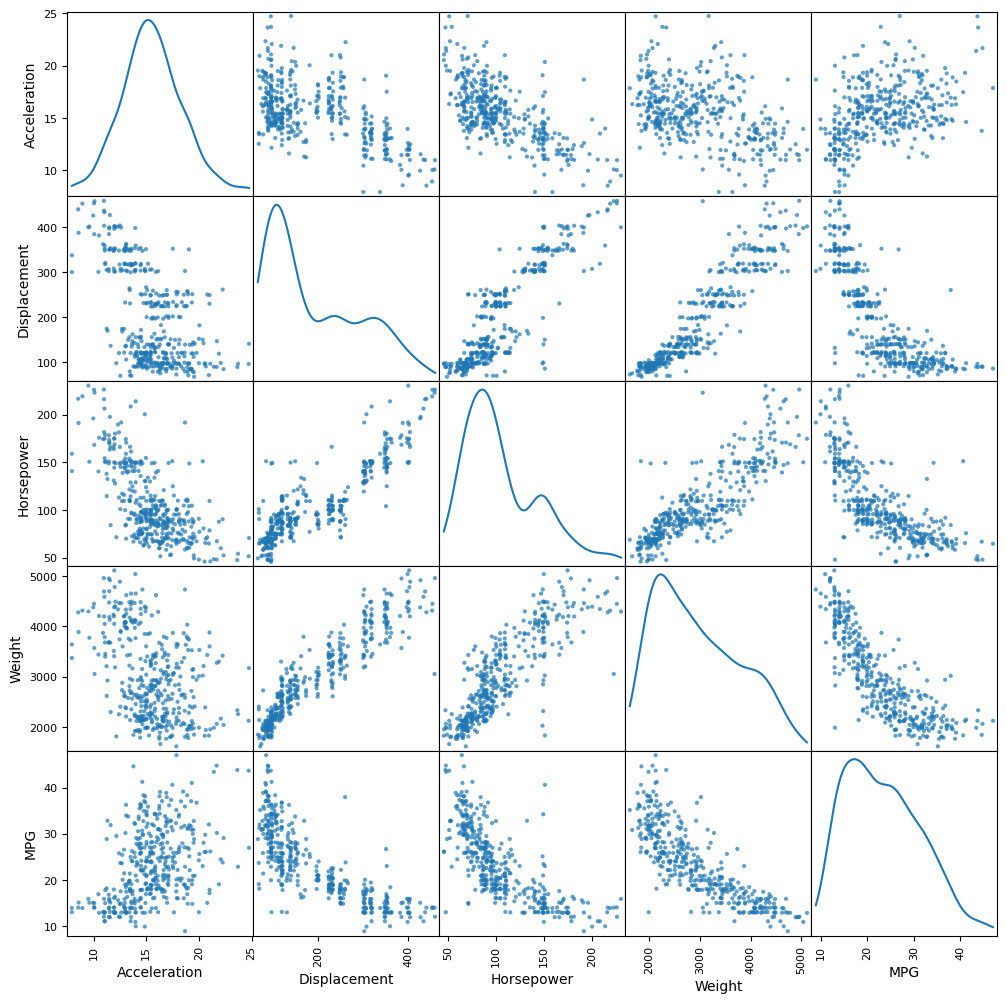

In [46]:
#ZADANIE 10
scatter_matrix(df_num, figsize=(12, 12), diagonal='kde', alpha=0.7)
plt.show()

    MPG    Zuzycie
0  18.0  13.159722
1  15.0  15.791667
2  18.0  13.159722
3  16.0  14.804688
4  17.0  13.933824


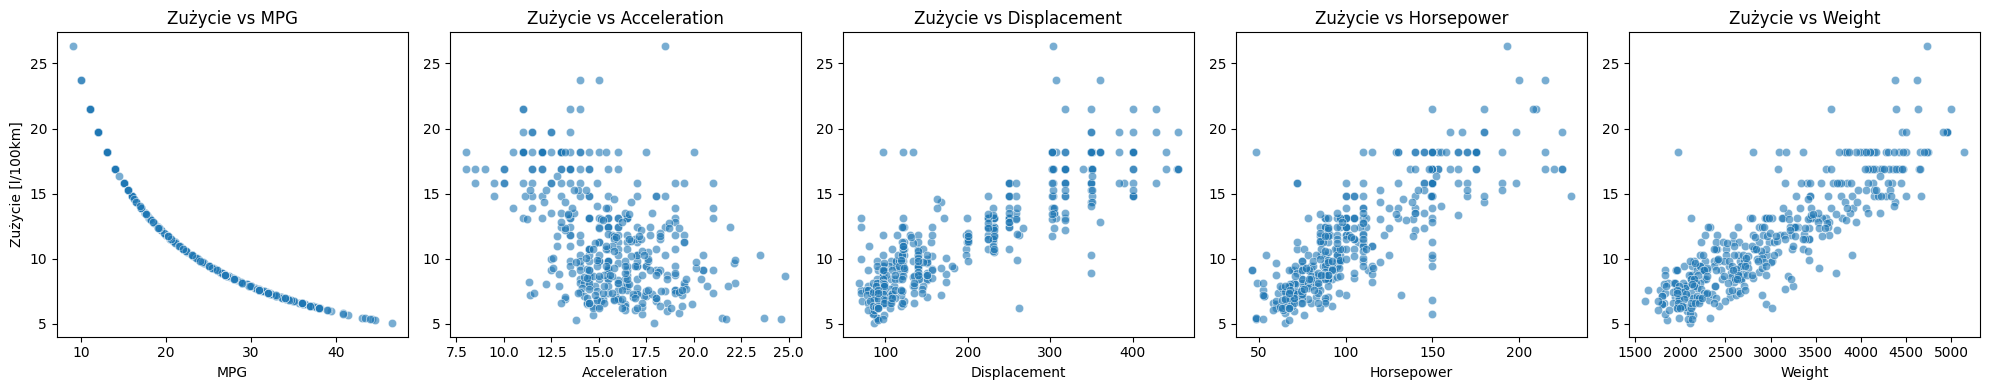

In [53]:
#ZADANIE 11
miles_per_100km = 100 / 1.6
gallons_per_100km = miles_per_100km / data['MPG']
liters_per_100km = gallons_per_100km * 3.79

data['Zuzycie'] = liters_per_100km
print(data[['MPG', 'Zuzycie']].head())


fig, axes = plt.subplots(1, 5, figsize=(20, 4))

x_vars = ['MPG', 'Acceleration', 'Displacement', 'Horsepower', 'Weight']

for i, var in enumerate(x_vars):
    axes[i].scatter(data[var], data['Zuzycie'], alpha=0.6, edgecolors='w', linewidth=0.5)
    axes[i].set_title(f'Zużycie vs {var}')
    axes[i].set_xlabel(var)
    if i == 0:
        axes[i].set_ylabel('Zużycie [l/100km]')

plt.tight_layout()
plt.show()

In [55]:
#ZADANIE 12
mean_fuel_by_cyl = data.groupby('Cylinders')['Zuzycie'].mean().reset_index()
mean_fuel_by_cyl.columns = ['Liczba cylindrów', 'Średni zużycie']
display(mean_fuel_by_cyl)

,Liczba cylindrów,Średni zużycie
0,3,11.659749
1,4,8.534553
2,5,9.167354
3,6,12.191568
4,8,16.436886
